# XAI test 1



In [1]:

from XAI_test_1 import *


## simple linear combination test

### make example data 1

In [2]:

# 1. Setup & Data
X, y, feature_names = generate_linear_synthetic_data(
        num_inputs=10, 
        num_samples=5000, 
        num_contributing_features=(2, 5), 
        weight_range=(-3, 3),
        noise_std=0.05,
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info ---
Number of contributing variables (M): 5

--- True Mathematical Equation ---
y = (-2.5212 * Feature_0) + (2.3187 * Feature_9) + (-1.5025 * Feature_6) + (0.8259 * Feature_4) + (-0.0094 * Feature_2) + Noise(0, 0.05)
-----------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_0   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.979e+05
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:46:00   Log-Likelihood:                 6339.7
No. Observations:                4000   AIC:                        -1.266e+04
Df Residuals:                    3989   BIC:                        -1.259e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

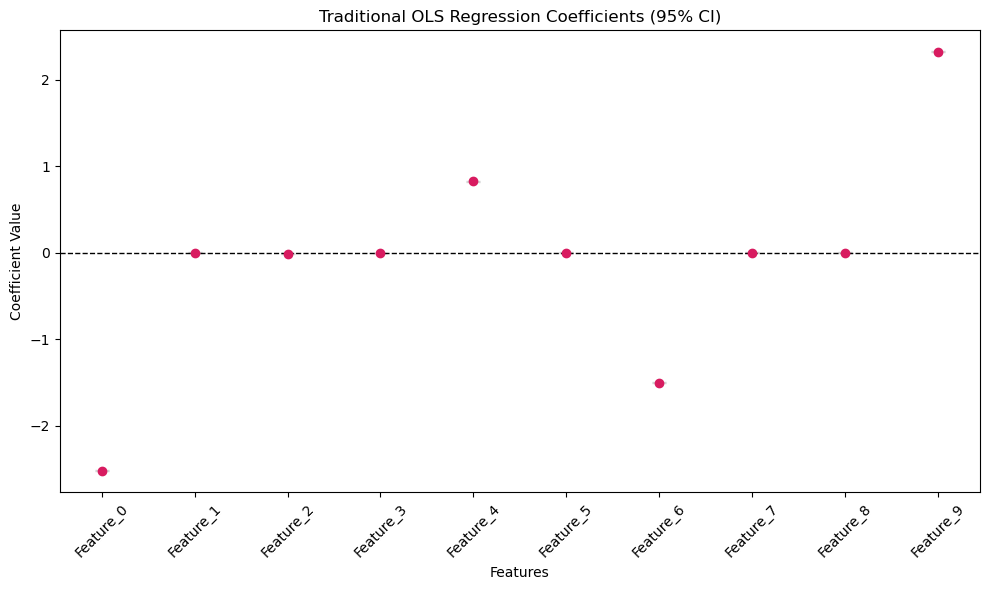


Statistically Significant Features (p < 0.05):
['Feature_0', 'Feature_2', 'Feature_4', 'Feature_6', 'Feature_9']


In [3]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [4]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(model, X_test, y_test)



--- XGBoost Model Evaluation ---
Mean Squared Error (MSE):       0.0091
Root Mean Squared Error (RMSE): 0.0954
Mean Absolute Error (MAE):      0.0763
R-squared Score:                0.9930
--------------------------------



### look at XGBoost Native Importances

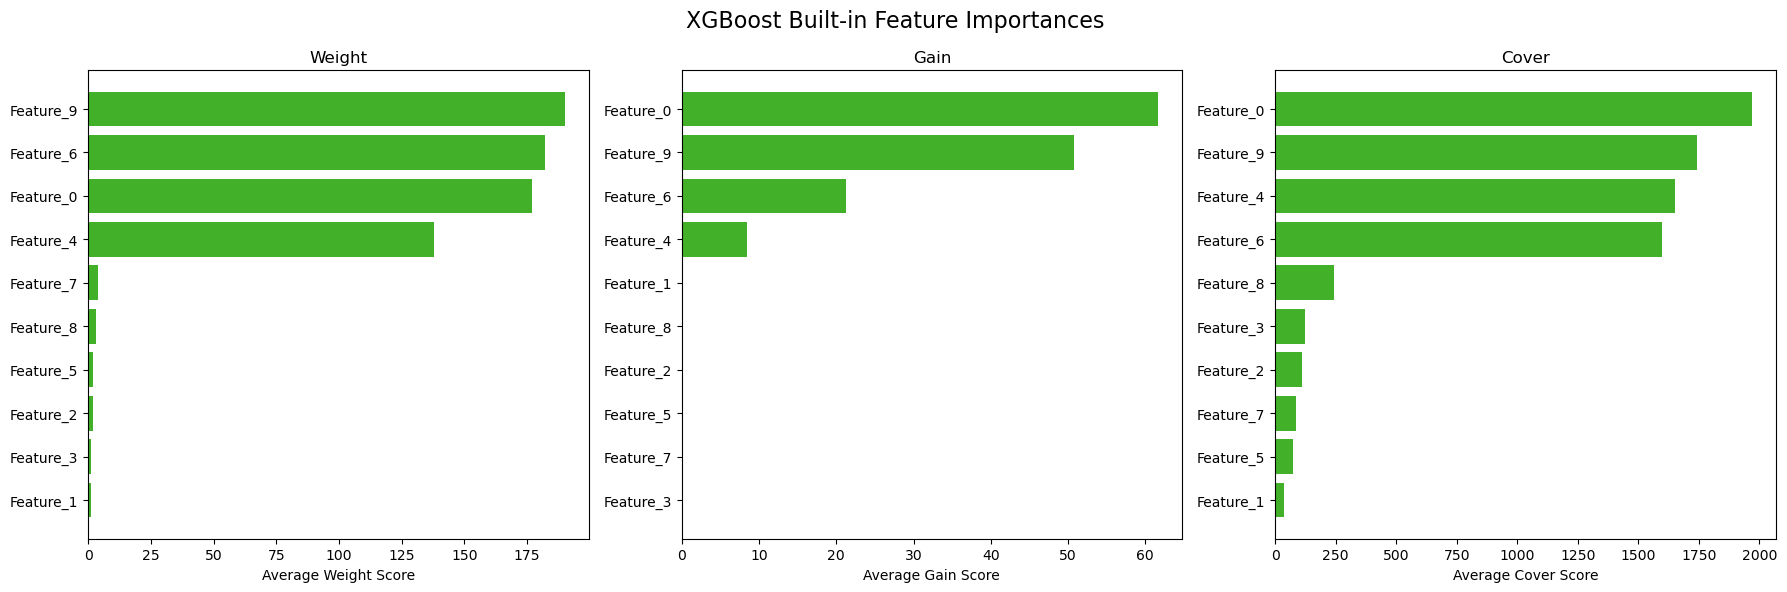

In [5]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [6]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


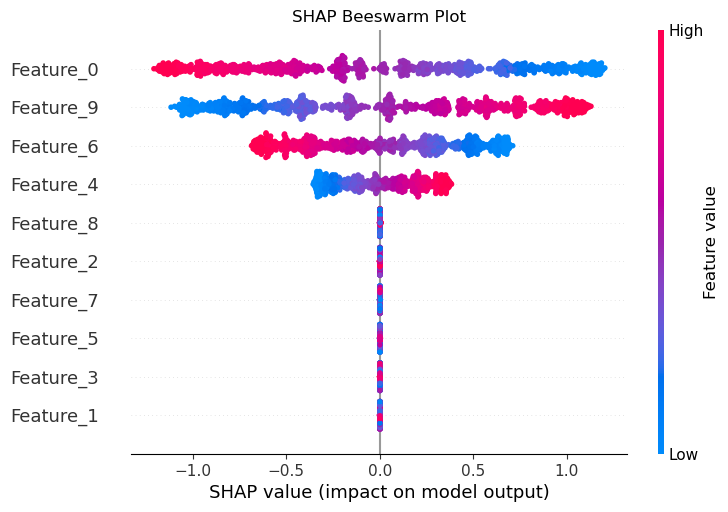

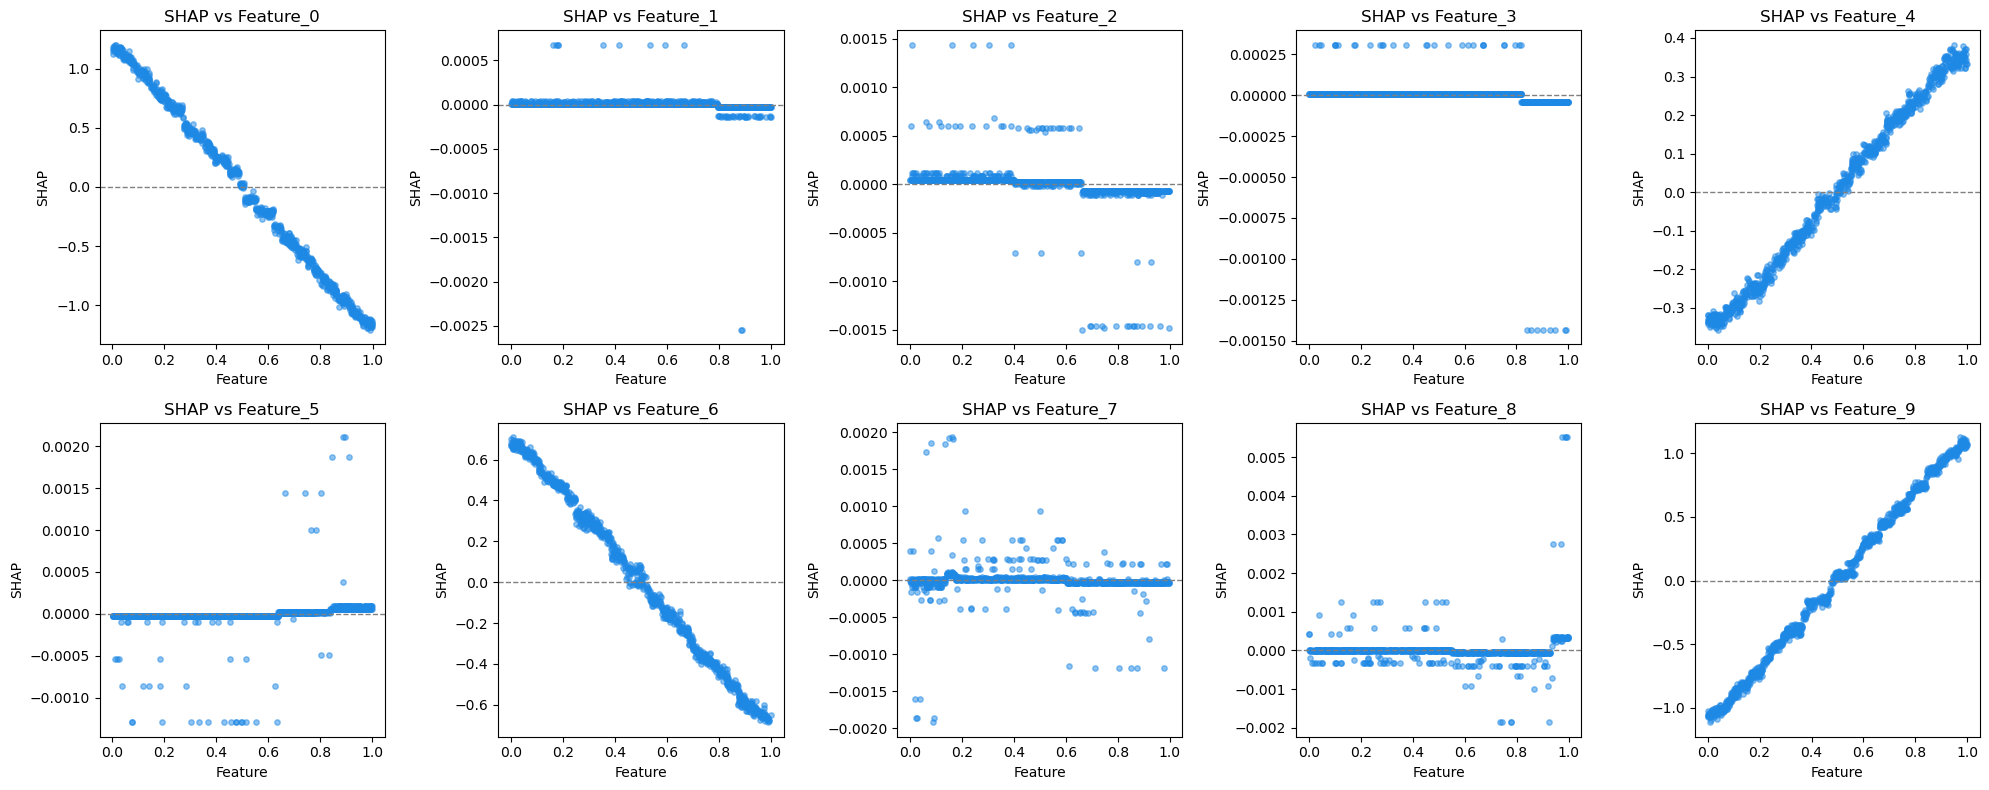

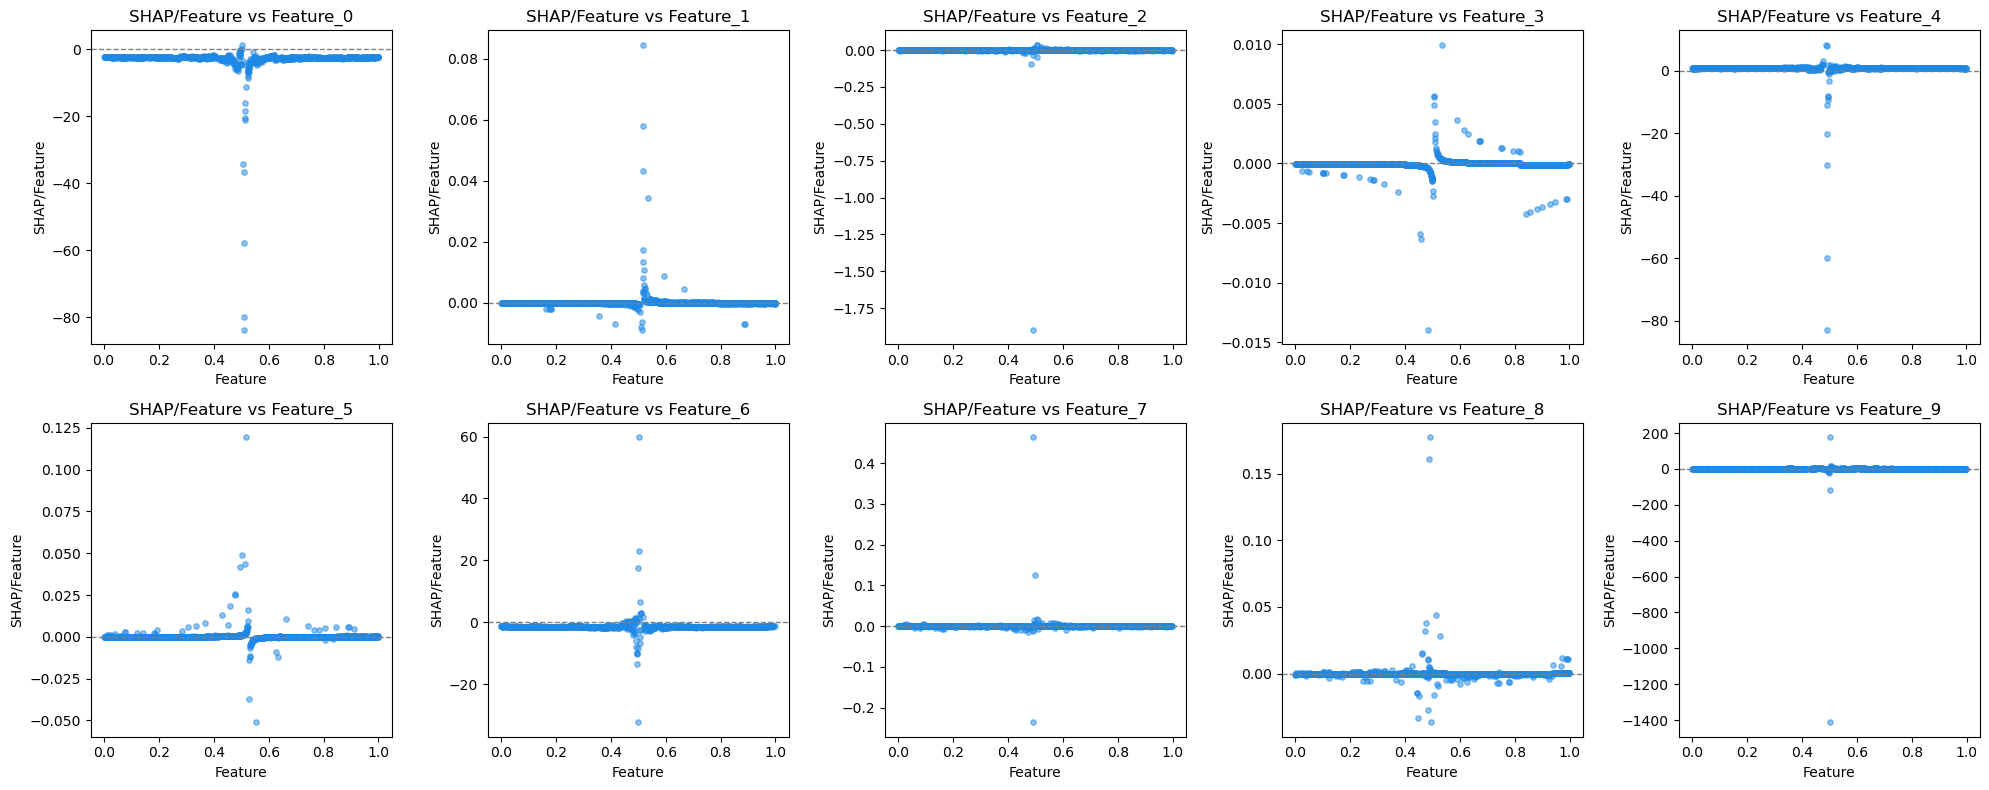

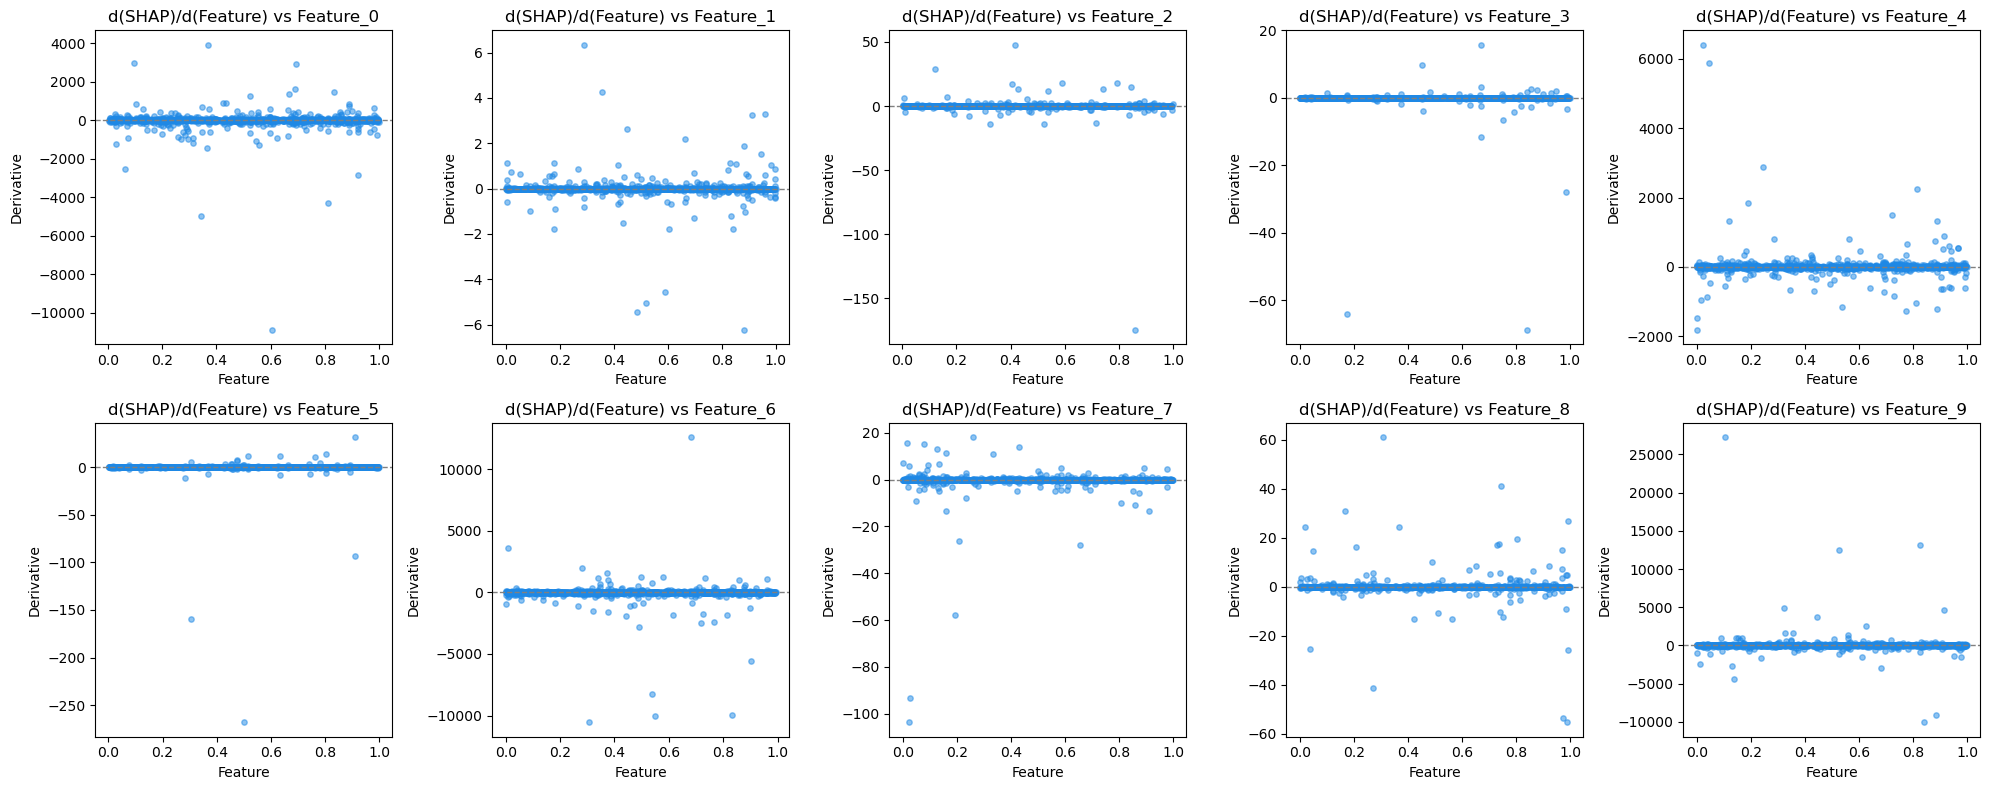

In [7]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


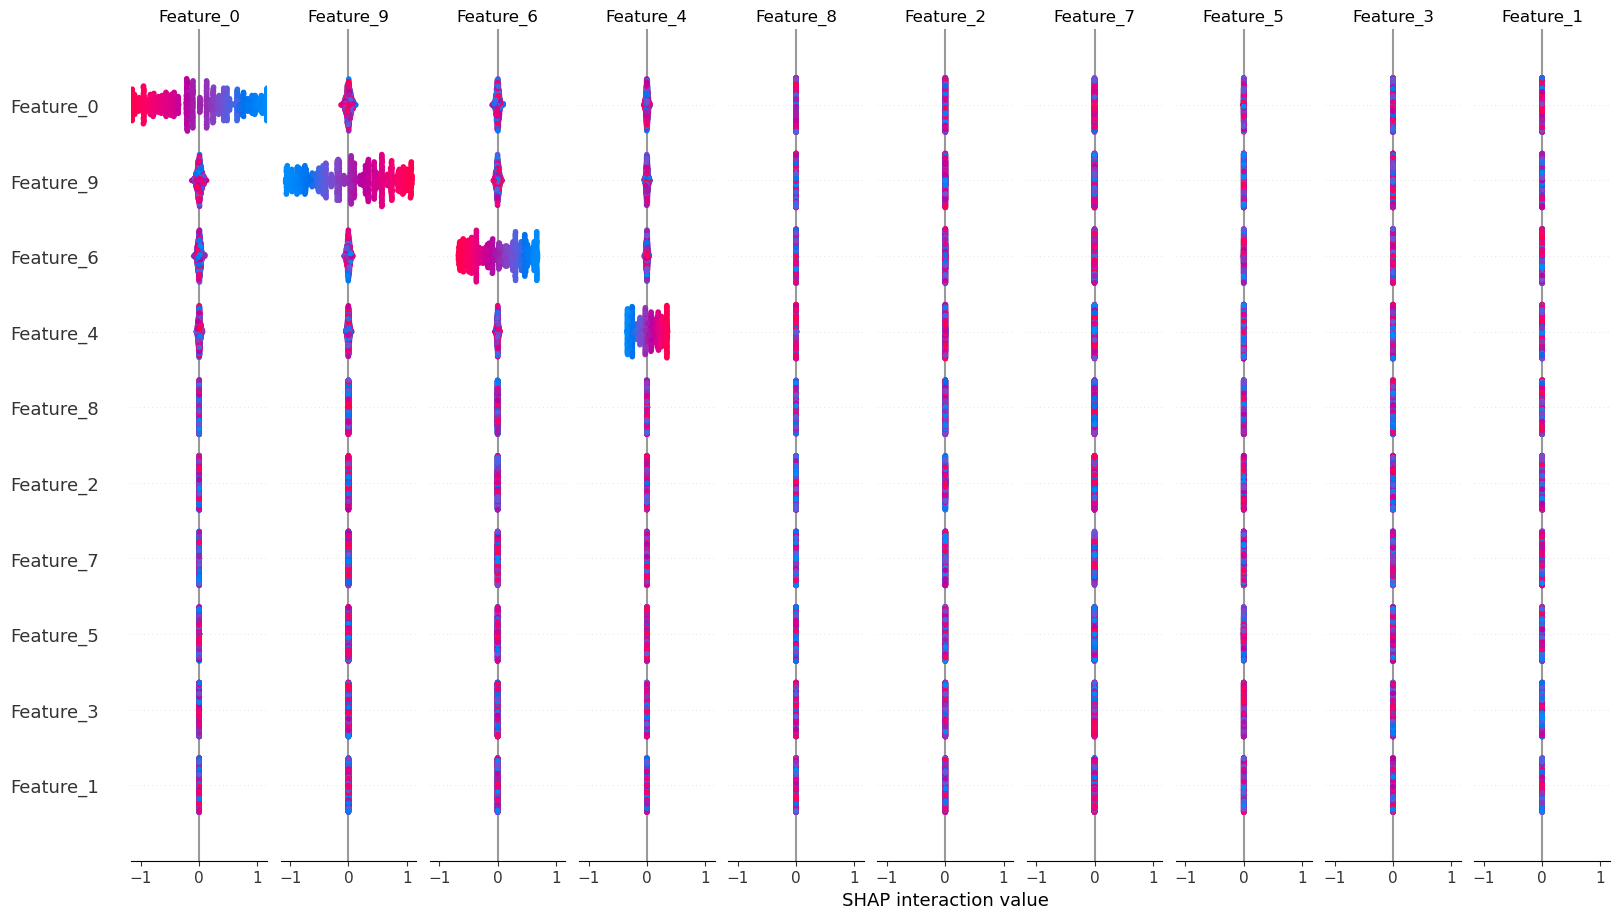


Strongest Interaction found by SHAP: Feature_9 & Feature_0
Plotting pure interaction effect for Feature_9 and Feature_0...


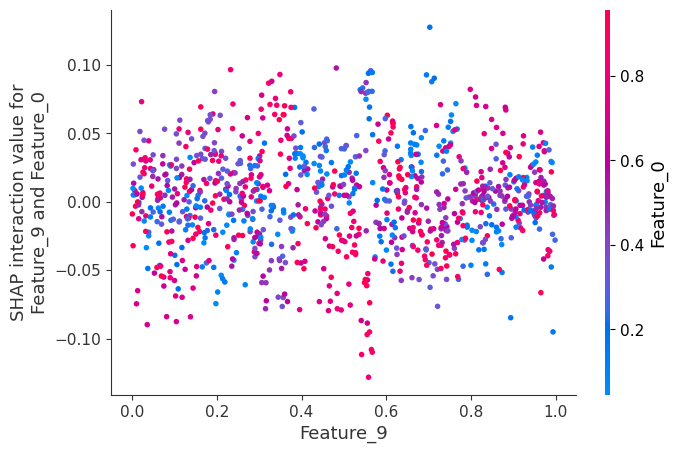

In [8]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [9]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_0: 0.6271
  Feature_9: 0.5887
  Feature_6: 0.3724
  Feature_4: 0.2007
  Feature_8: 0.0001
  Feature_2: 0.0001
  Feature_7: 0.0001
  Feature_5: 0.0001
  Feature_3: 0.0000
  Feature_1: 0.0000

Ranked Features (Most to Least Important):
['Feature_0', 'Feature_9', 'Feature_6', 'Feature_4', 'Feature_8', 'Feature_2', 'Feature_7', 'Feature_5', 'Feature_3', 'Feature_1']


## test for linear combination with some feature interactions

### make example data 2

In [10]:

# 1. Setup & Data
X, y, feature_names = generate_synthetic_data_with_interactions(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(2, 5), 
    weight_range=(-3, 3),
    num_interactions=(1, 2),
    interaction_weight_range=(-3, 3),
    noise_std=0.05,
)

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With Interactions) ---
Number of linear variables (M): 4
Number of interaction terms: 2

--- True Mathematical Equation ---
y = (2.9582 * Feature_8) + (-2.3847 * Feature_6) + (-0.8819 * Feature_1) + (0.1586 * Feature_3) + (-2.3883 * Feature_0 * Feature_1) + (1.3283 * Feature_0 * Feature_2) + Noise(0, 0.05)
-------------------------------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_1   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 1.222e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:46:08   Log-Likelihood:                 209.56
No. Observations:                4000   AIC:                            -397.1
Df Residuals:                    3989   BIC:                            -327.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

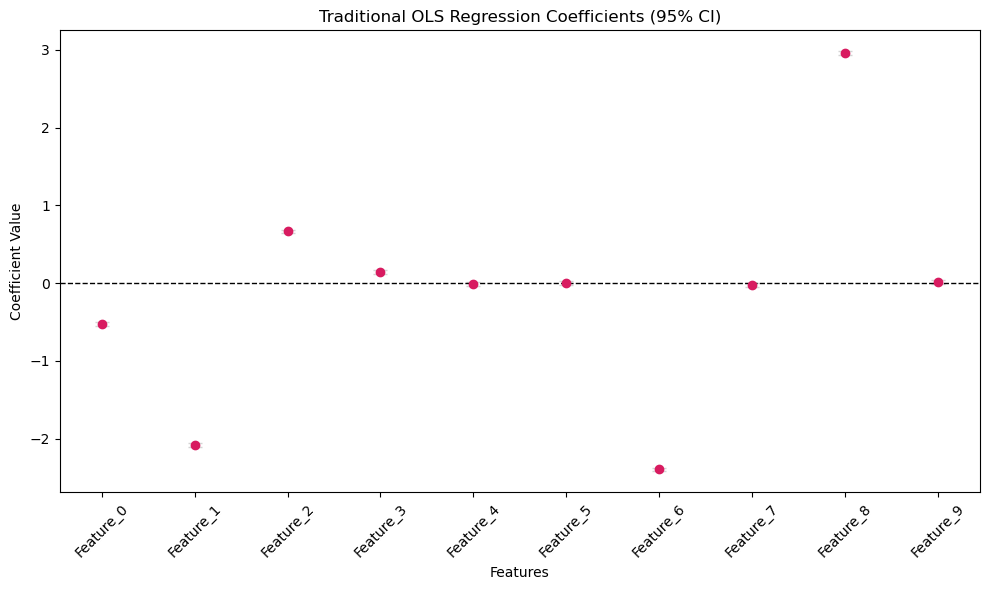


Statistically Significant Features (p < 0.05):
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_6', 'Feature_7', 'Feature_8']


In [11]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 2

In [12]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(model, X_test, y_test)
# 


--- XGBoost Model Evaluation ---
Mean Squared Error (MSE):       0.0243
Root Mean Squared Error (RMSE): 0.1558
Mean Absolute Error (MAE):      0.1229
R-squared Score:                0.9863
--------------------------------



### look at XGBoost Native Importances

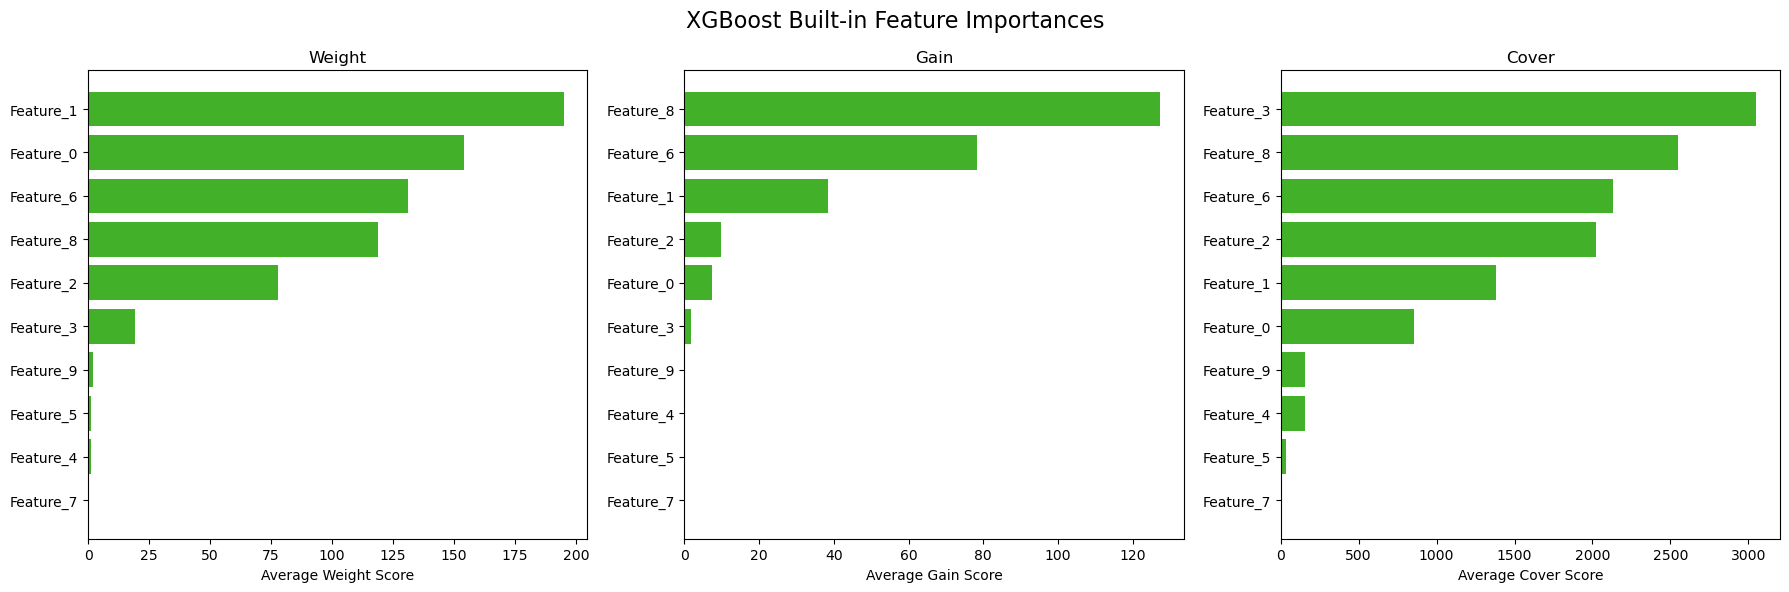

In [13]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [14]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


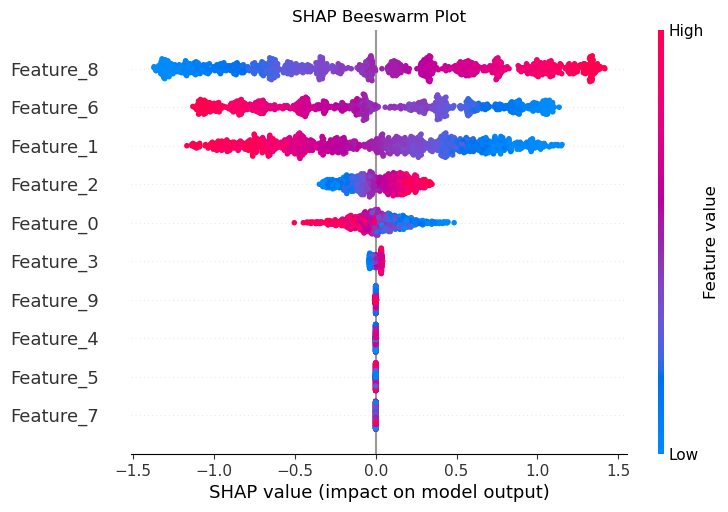

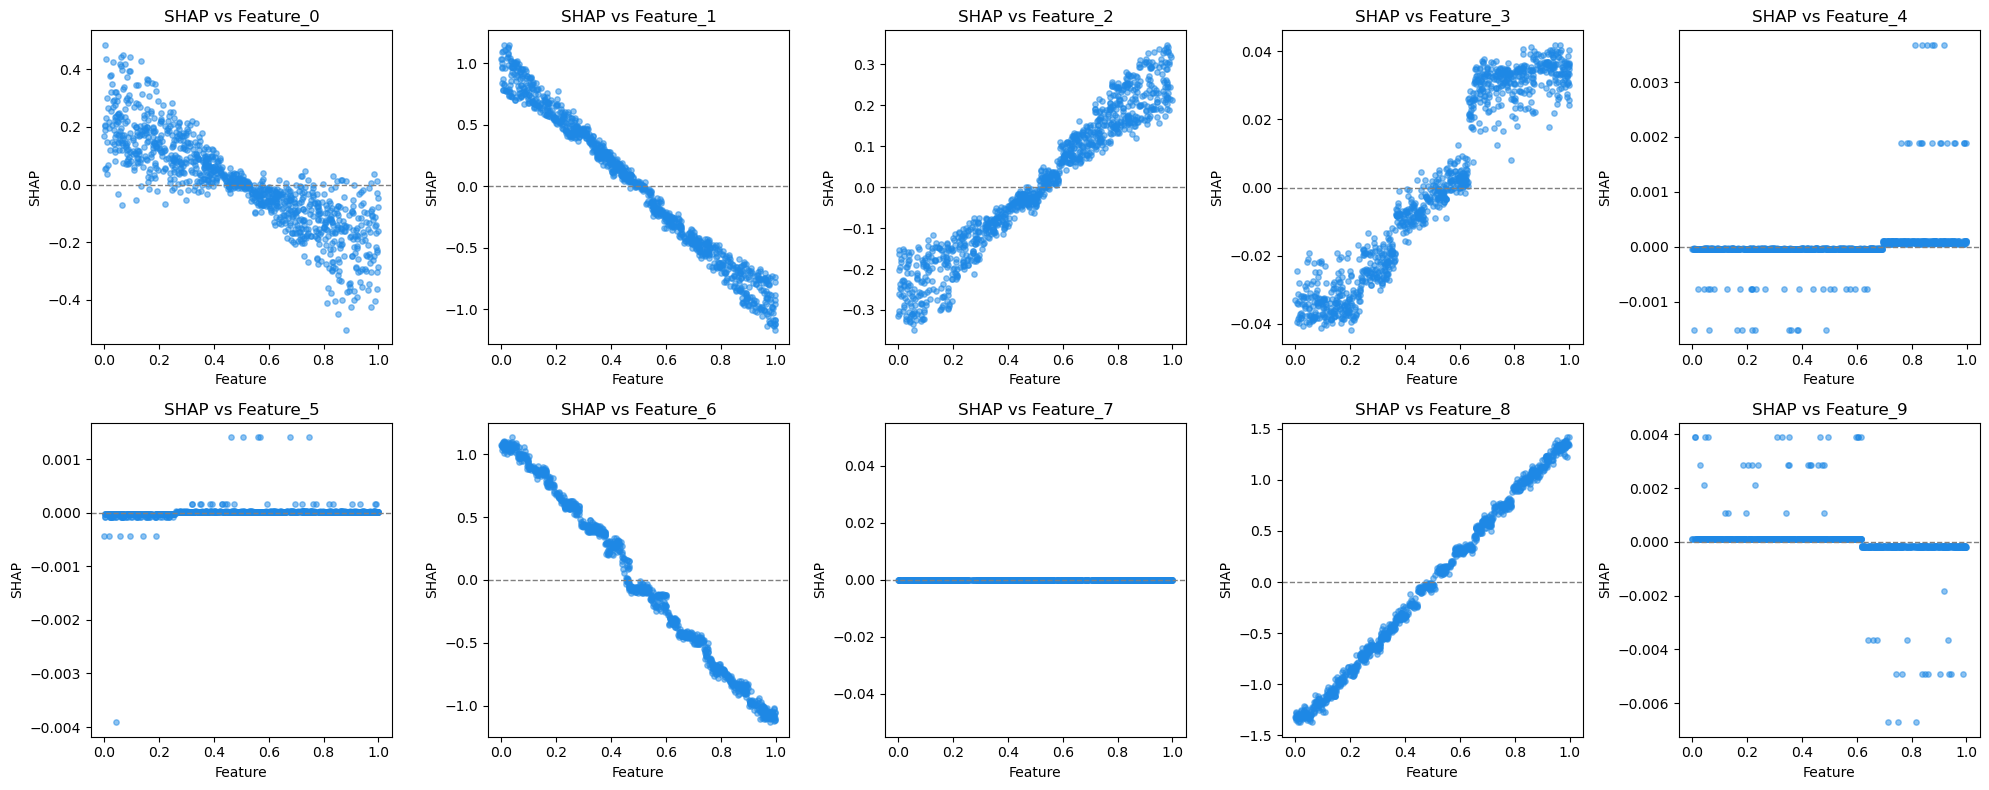

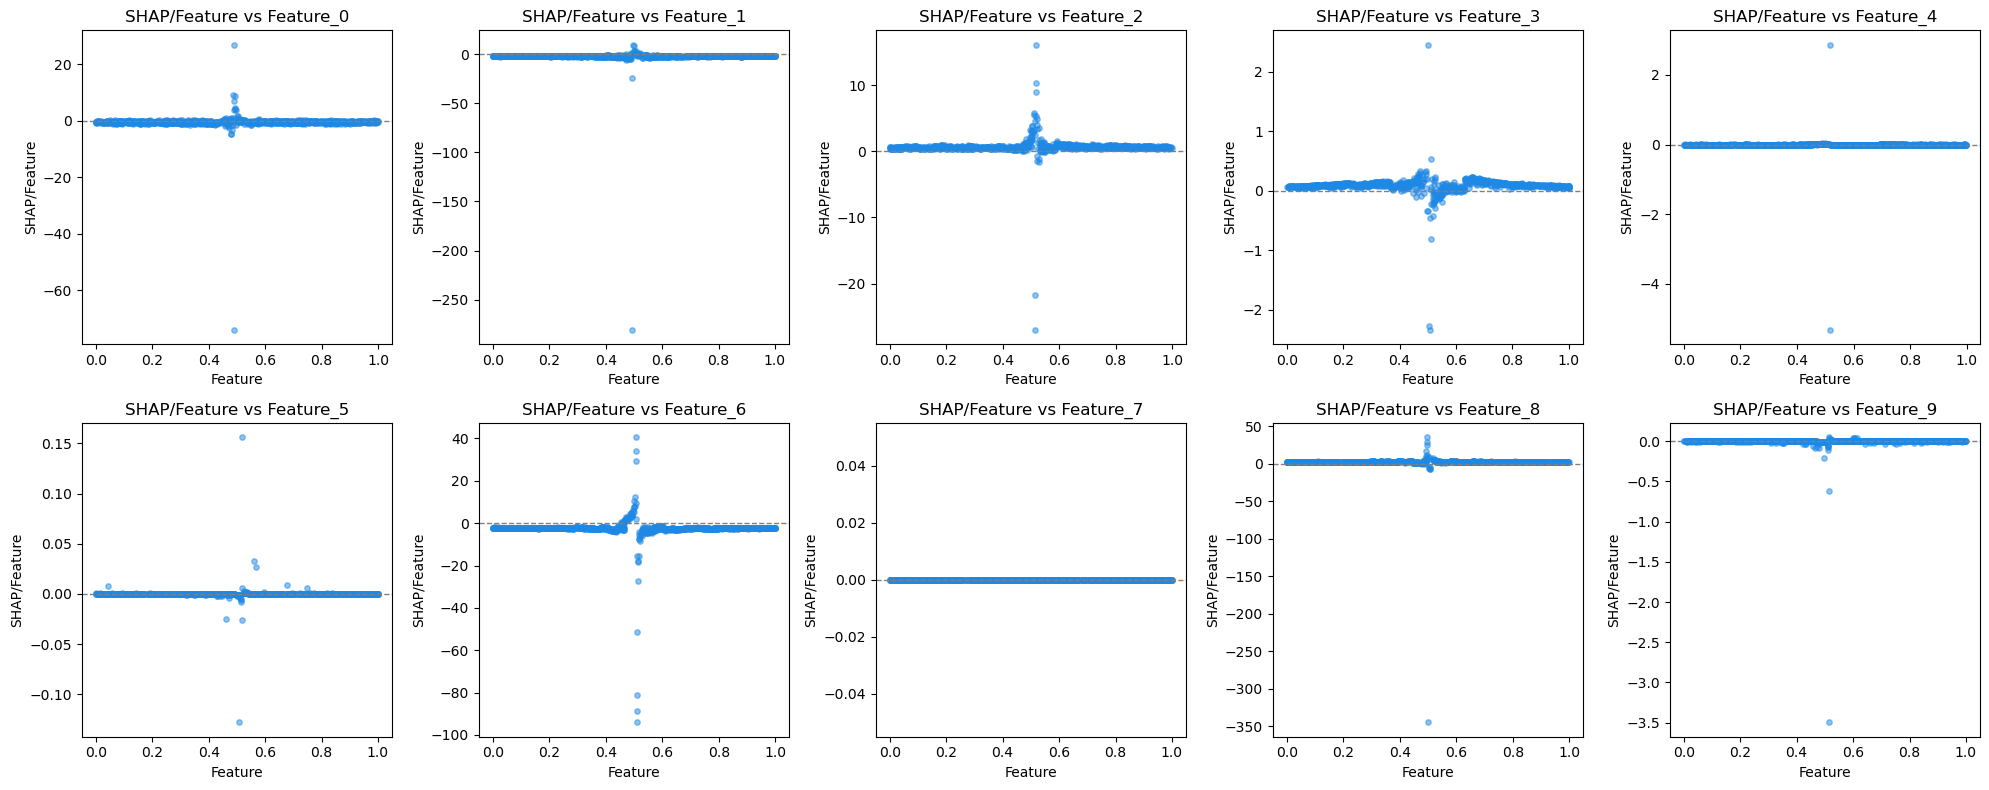

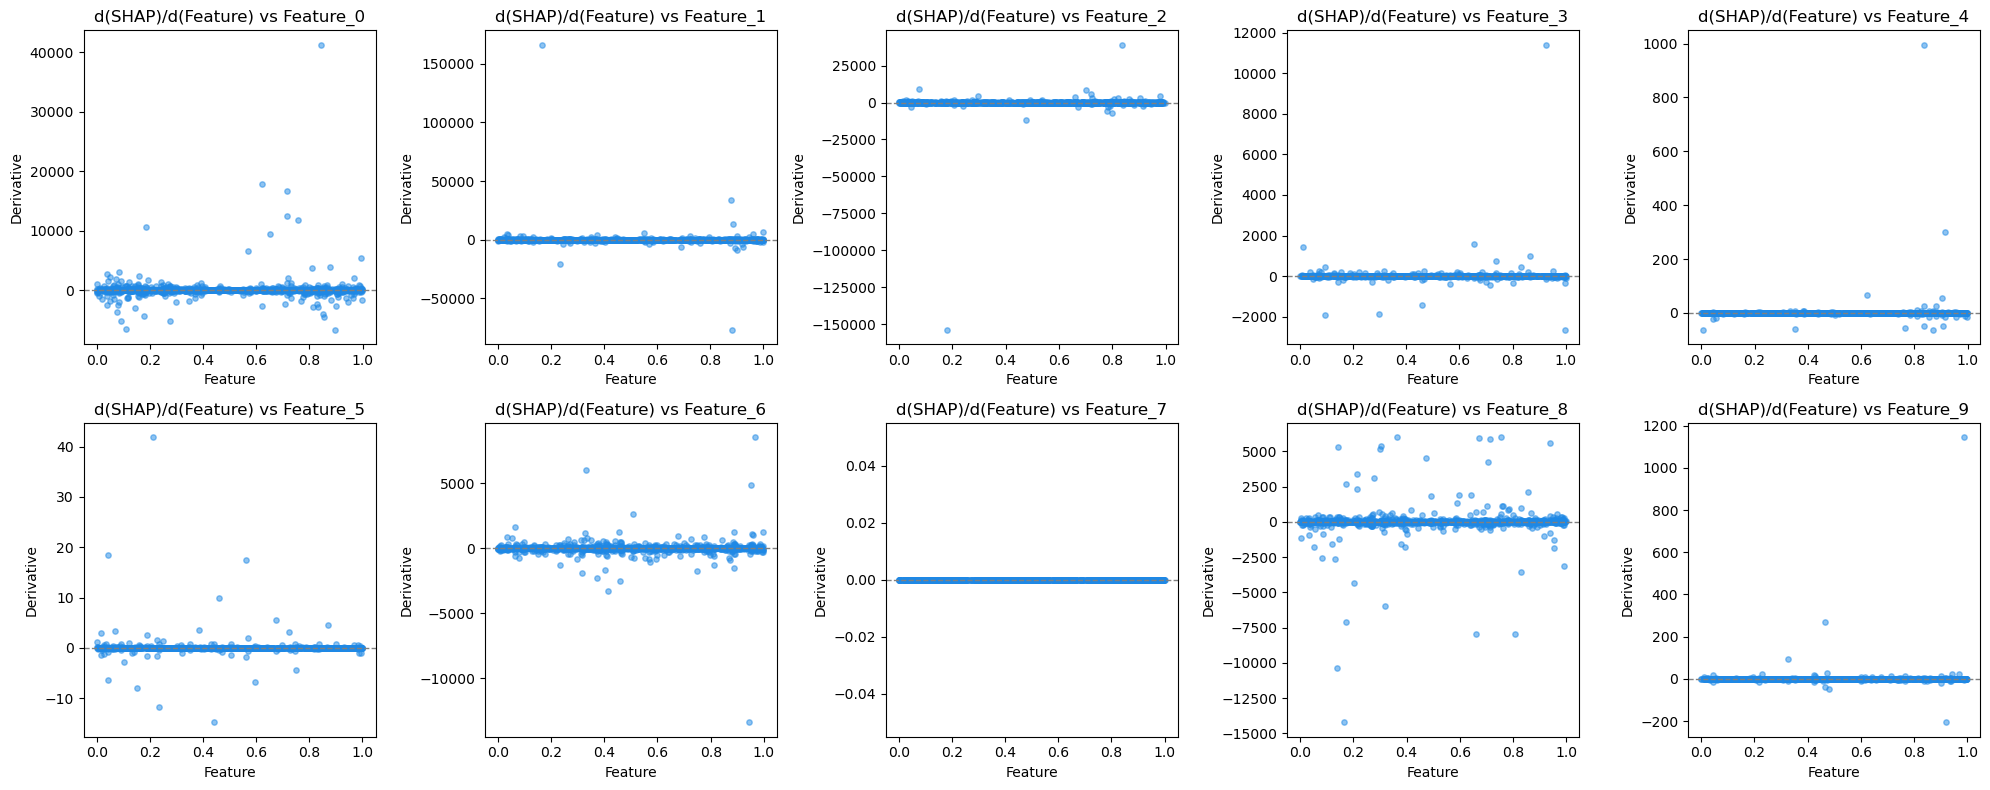

In [15]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


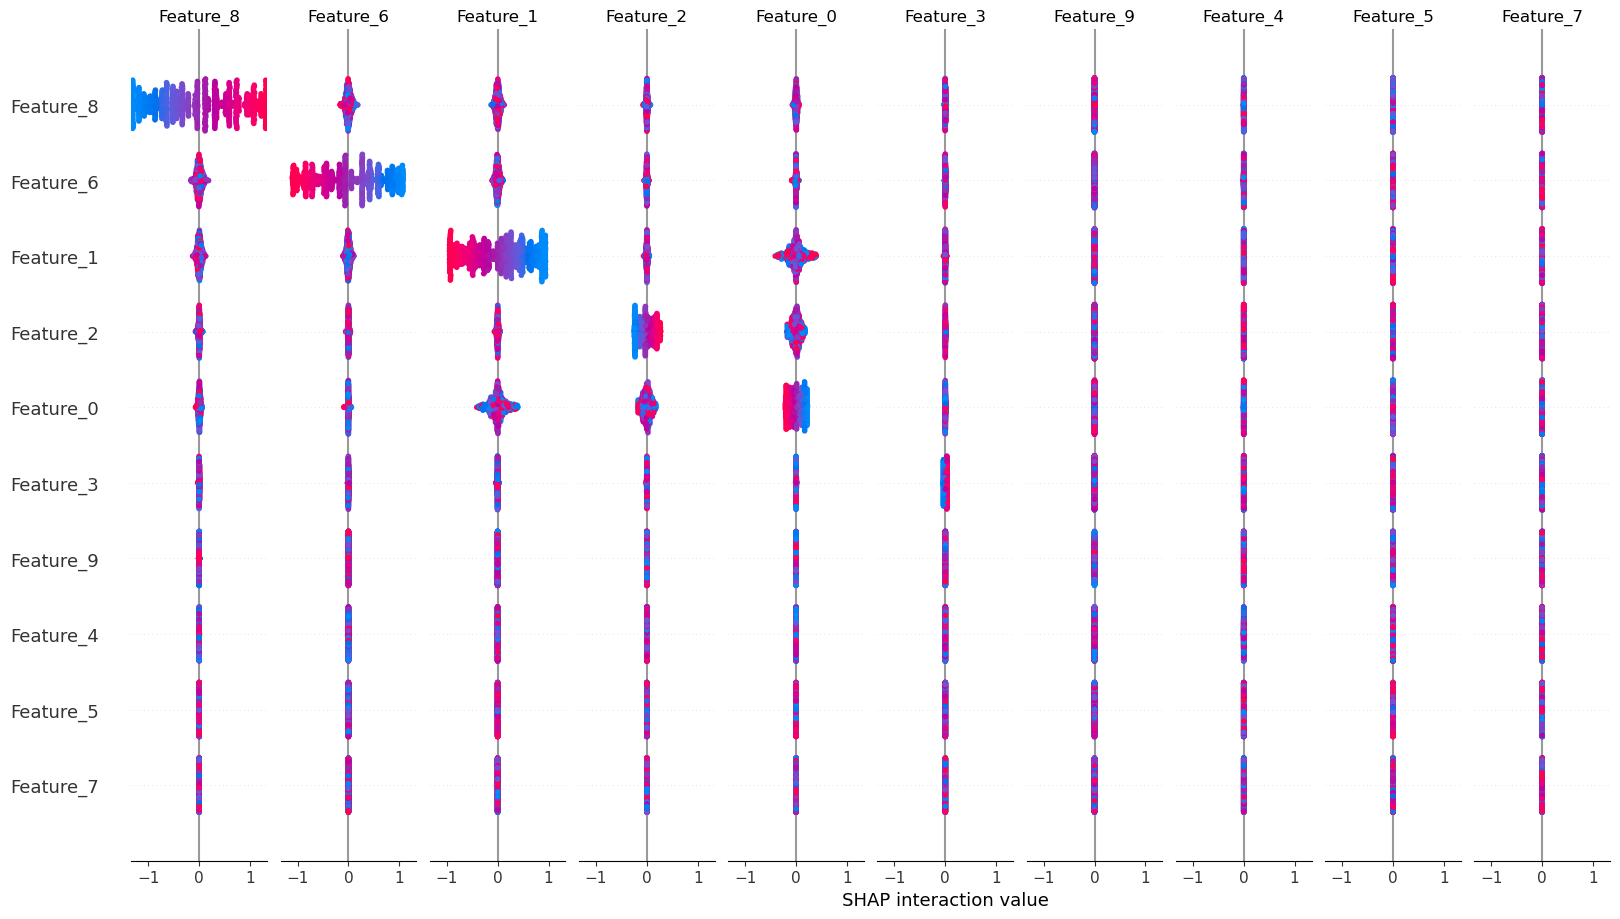


Strongest Interaction found by SHAP: Feature_0 & Feature_1
Plotting pure interaction effect for Feature_0 and Feature_1...


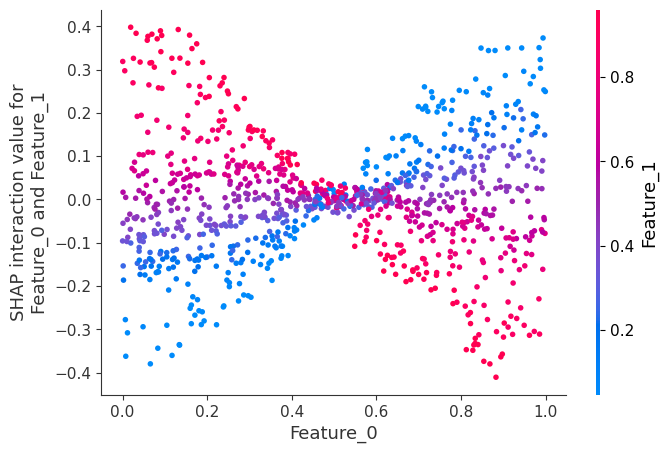

In [16]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [17]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_8: 0.7281
  Feature_6: 0.5882
  Feature_1: 0.5084
  Feature_2: 0.1459
  Feature_0: 0.1229
  Feature_3: 0.0237
  Feature_9: 0.0003
  Feature_4: 0.0001
  Feature_5: 0.0000
  Feature_7: 0.0000

Ranked Features (Most to Least Important):
['Feature_8', 'Feature_6', 'Feature_1', 'Feature_2', 'Feature_0', 'Feature_3', 'Feature_9', 'Feature_4', 'Feature_5', 'Feature_7']


## test for addition of hidden features

### make example data 3

In [18]:

# 1. Setup & Data
X, hidden_featues, y, feature_names, hidden_feature_names = generate_synthetic_data_with_hidden_features(
    num_inputs = 10, 
    num_samples = 5000, 
    num_contributing_features = (2, 5), 
    num_hidden_features = (1, 2), 
    weight_range = (-3, 3), 
    num_interactions = (1, 2), 
    interaction_weight_range = (-3, 3), 
    noise_std = 0.05, 
    hidden_in_linear = True,           # Should hidden features have a linear impact?
    hidden_in_interactions = True,     # Should hidden features be part of interactions?
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
Number of linear variables: 7 (5 visible, 2 hidden)
Number of interaction terms: 1

--- True Mathematical Equation ---
y = (-2.2921 * Feature_4) + (1.3249 * Feature_0) + (-1.1428 * Feature_3) + (-0.9240 * Hidden_1) + (0.6544 * Feature_2) + (0.5052 * Feature_8) + (-0.1373 * Hidden_0) + (0.8841 * Feature_2 * Hidden_0) + Noise(0, 0.05)
----------------------------------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_8   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     3669.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:46:15   Log-Likelihood:                -776.94
No. Observations:                4000   AIC:                             1576.
Df Residuals:                    3989   BIC:                             1645.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

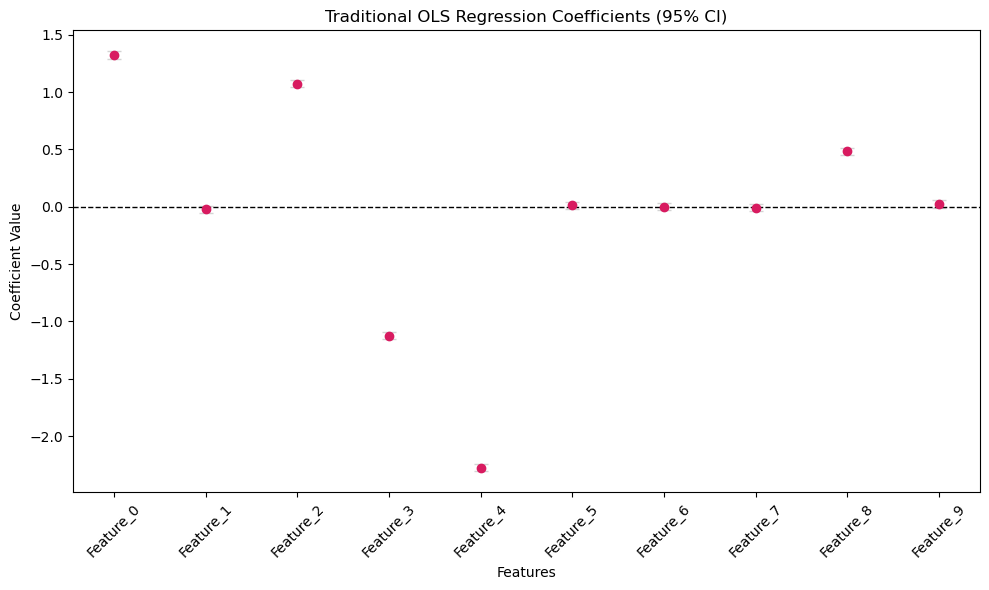


Statistically Significant Features (p < 0.05):
['Feature_0', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_8']


In [19]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 3

In [20]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

# Evaluate the XGBoost Model on the test set
evaluate_xgb_model(model, X_test, y_test)



--- XGBoost Model Evaluation ---
Mean Squared Error (MSE):       0.0979
Root Mean Squared Error (RMSE): 0.3129
Mean Absolute Error (MAE):      0.2561
R-squared Score:                0.8934
--------------------------------



### look at XGBoost Native Importances

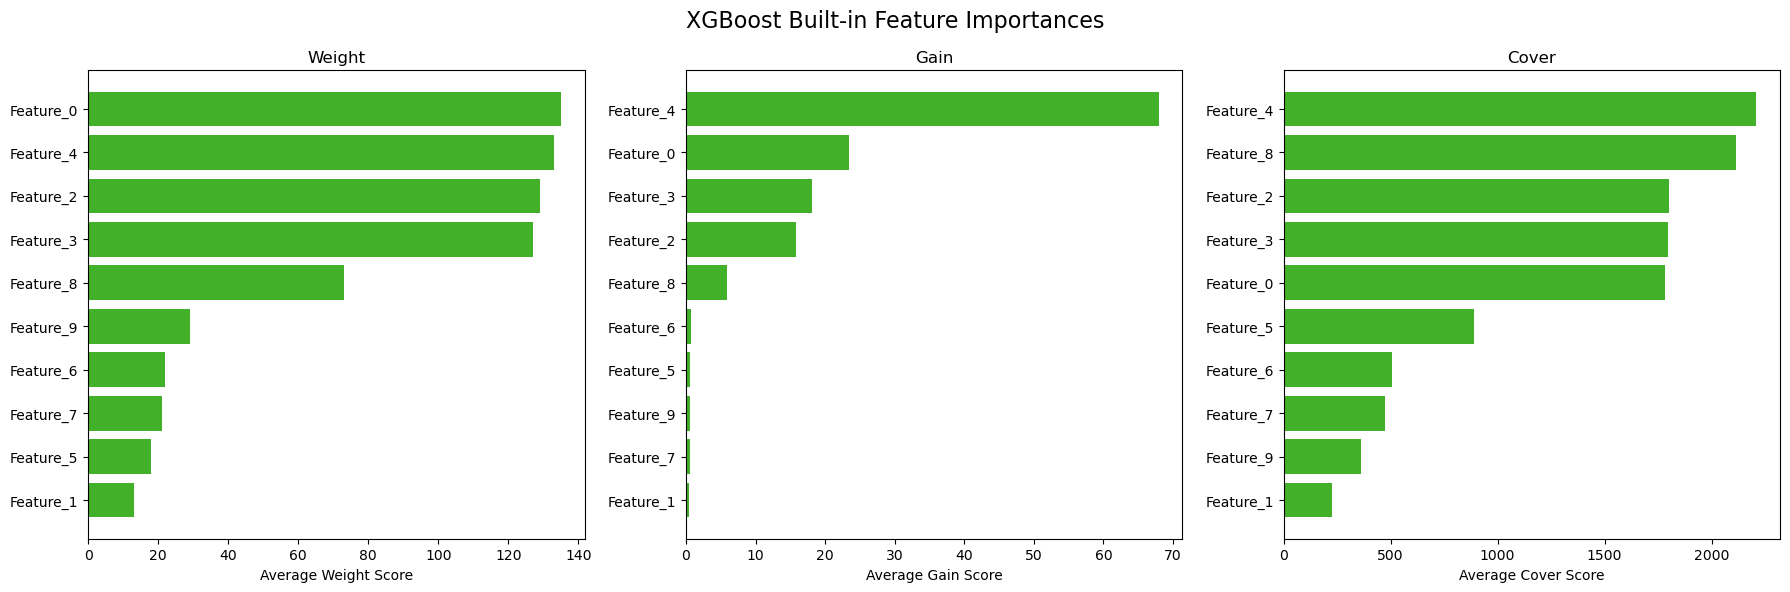

In [21]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [22]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


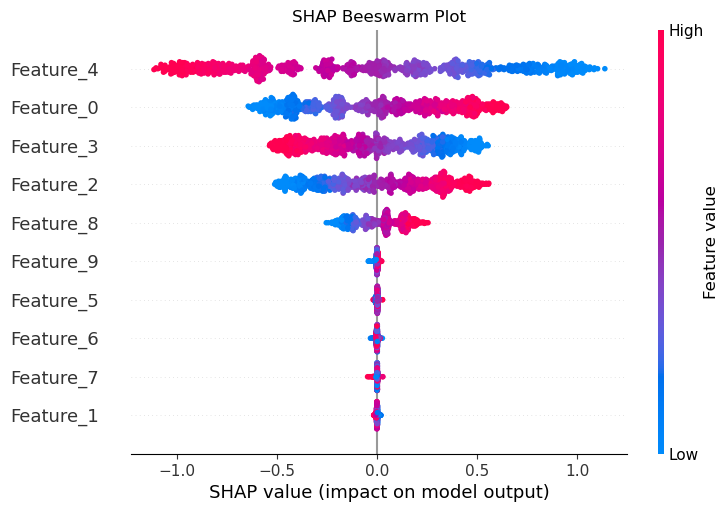

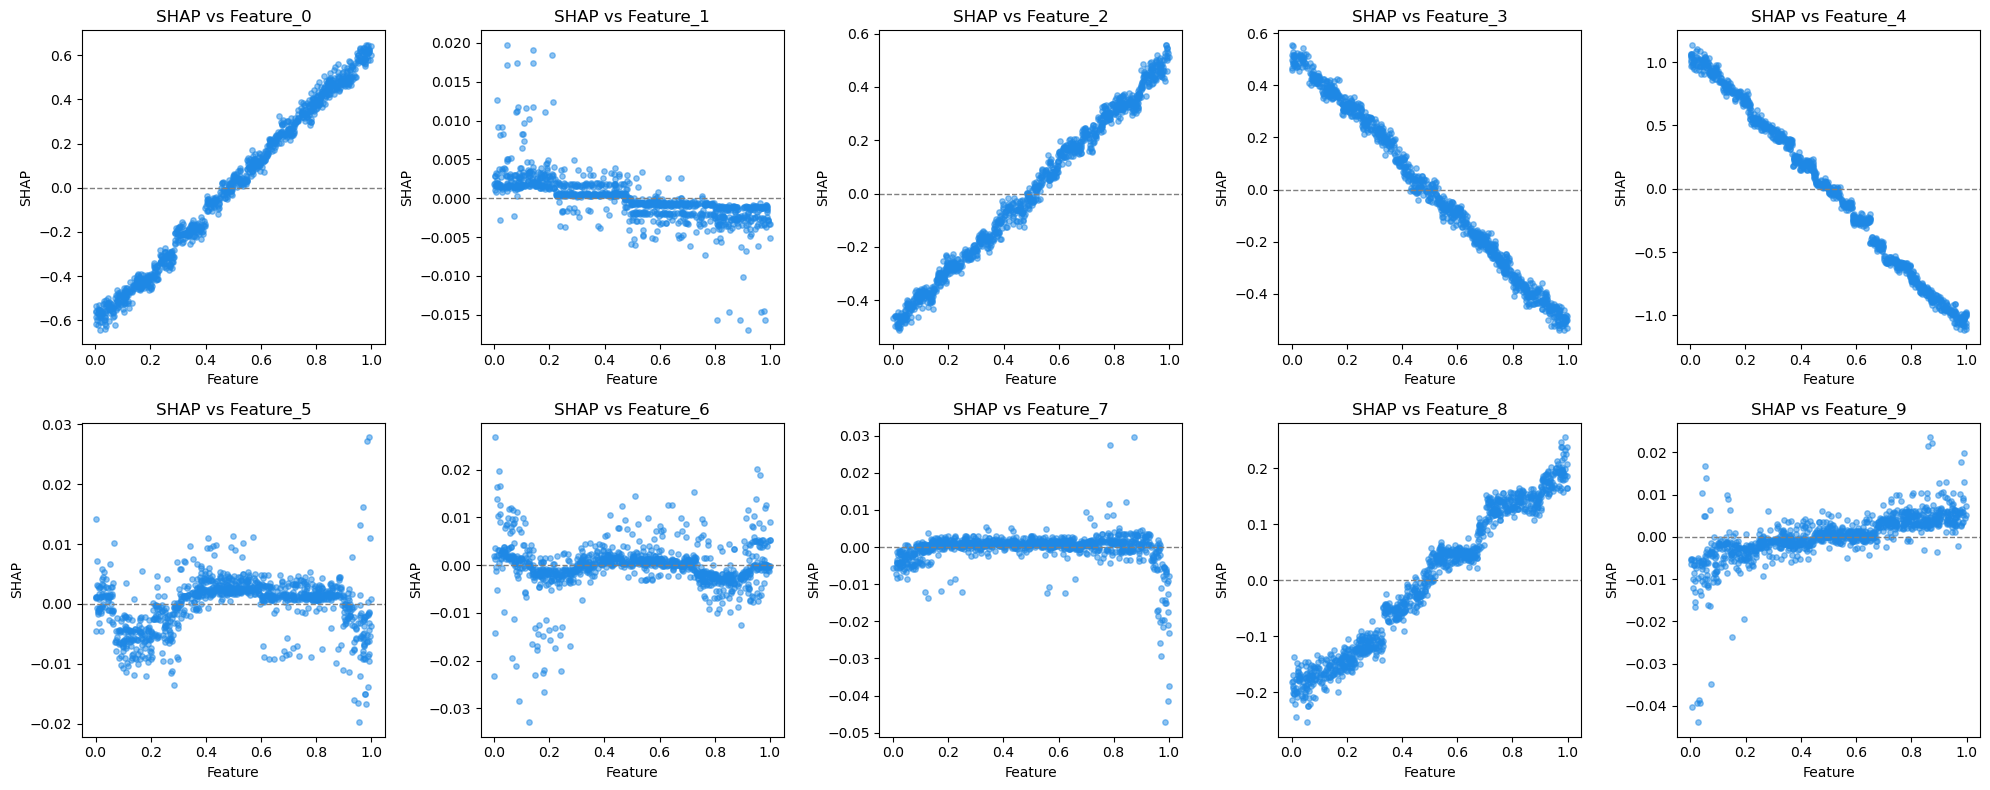

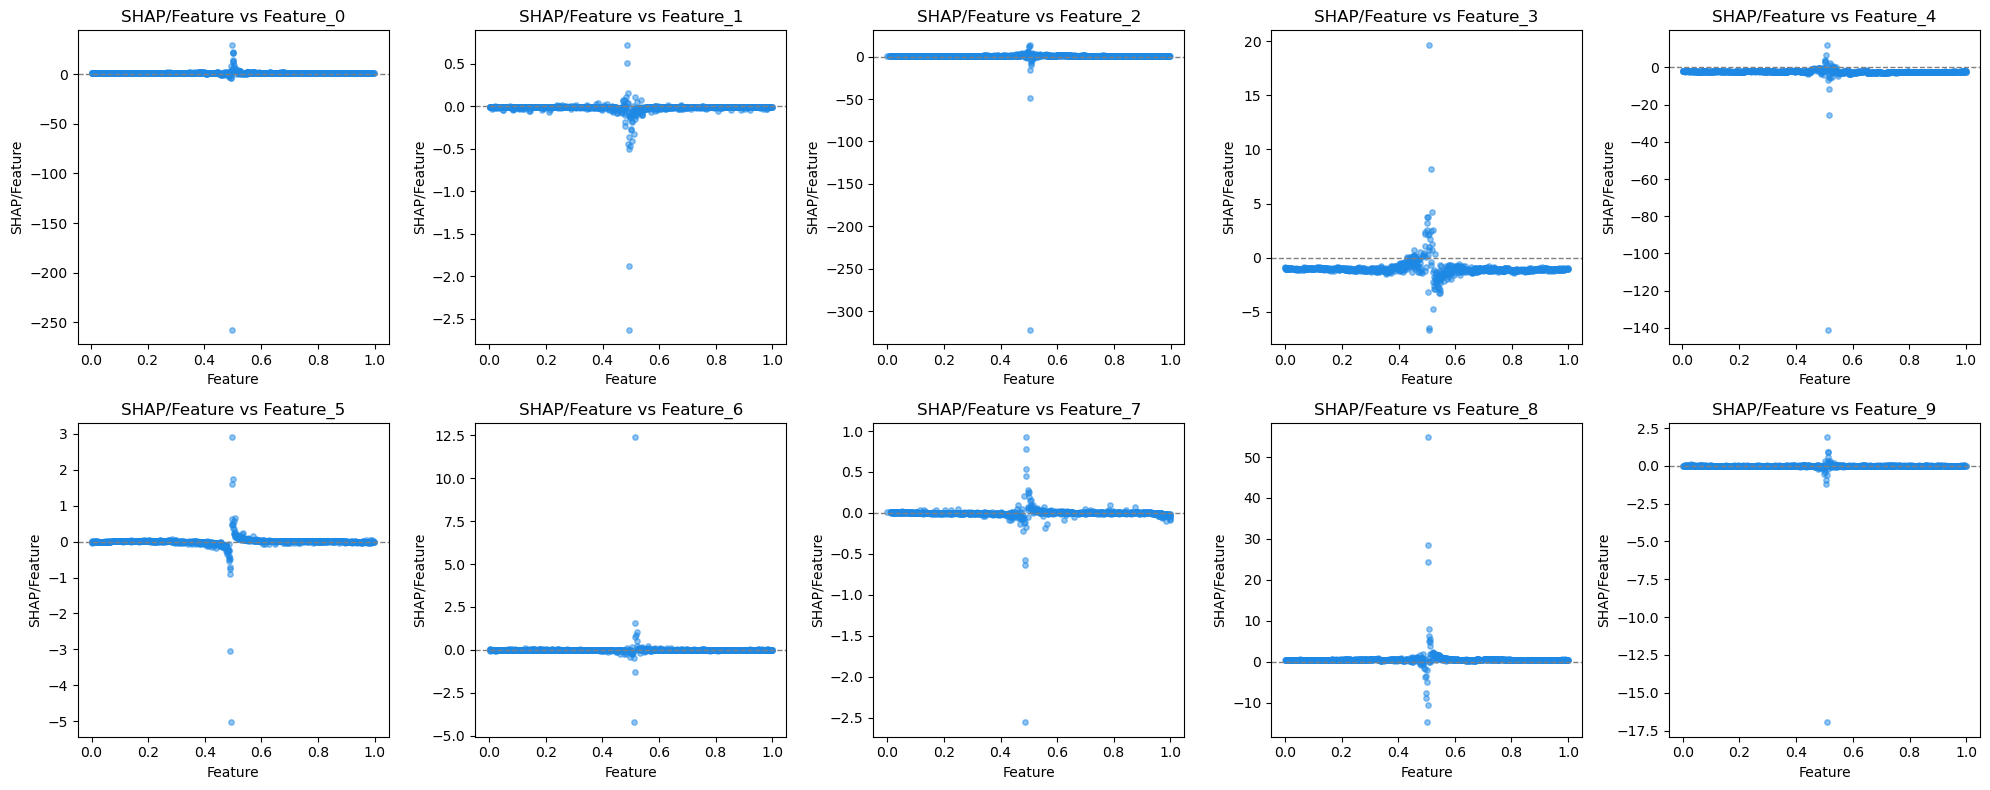

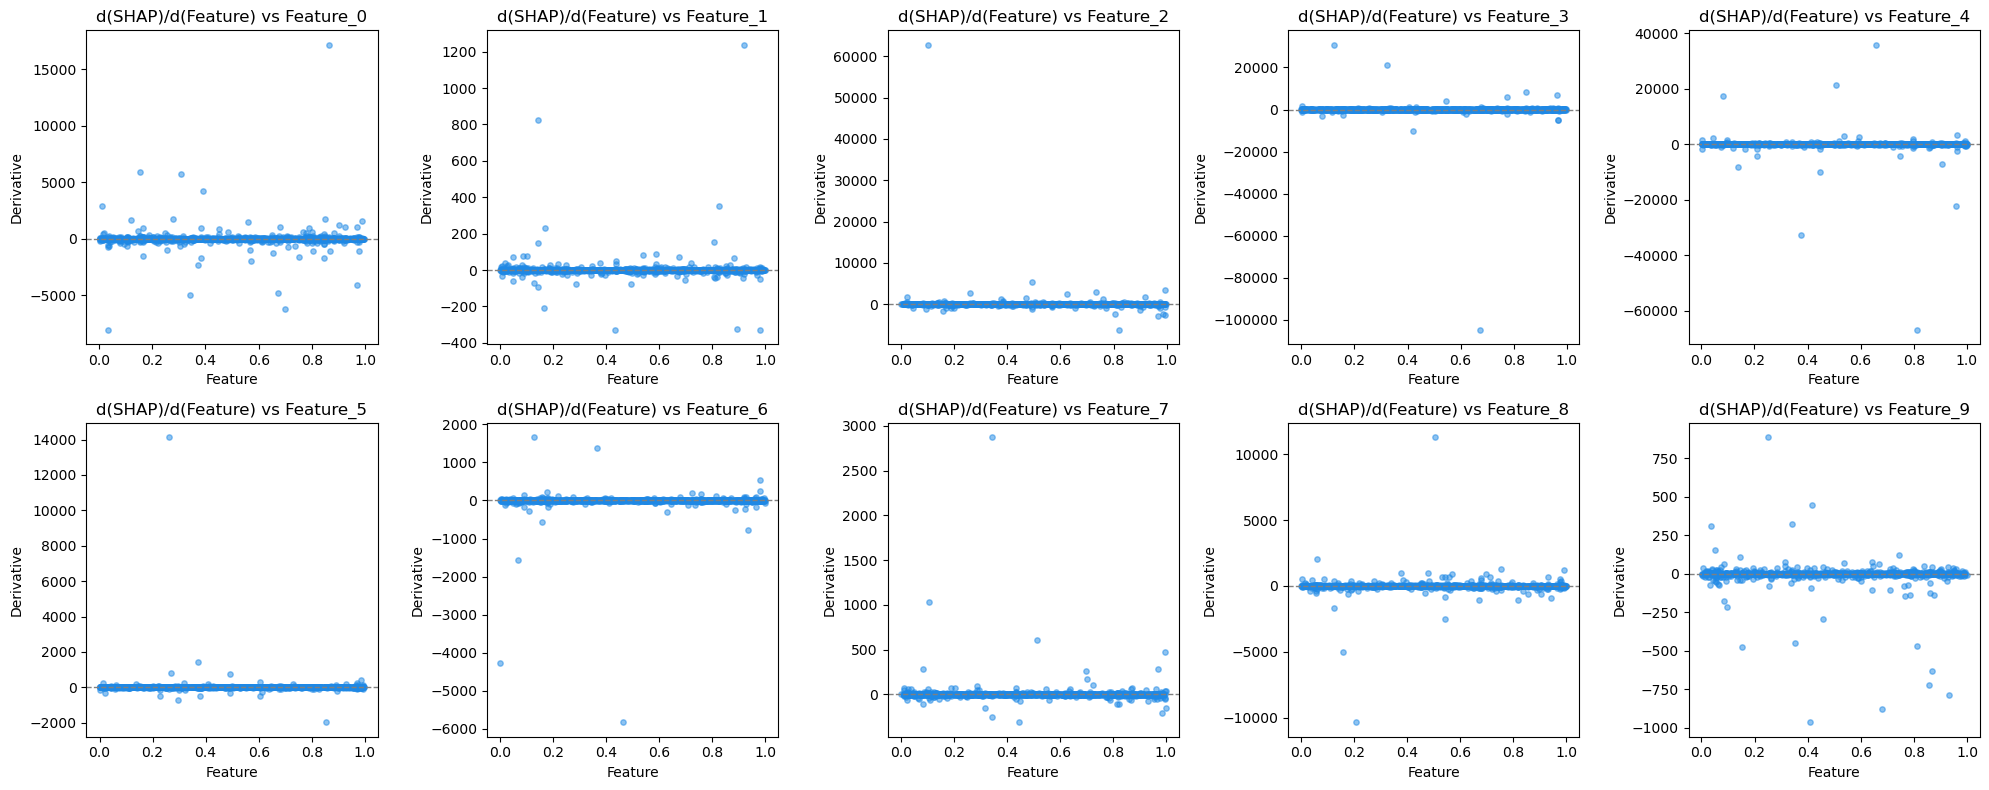

In [23]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


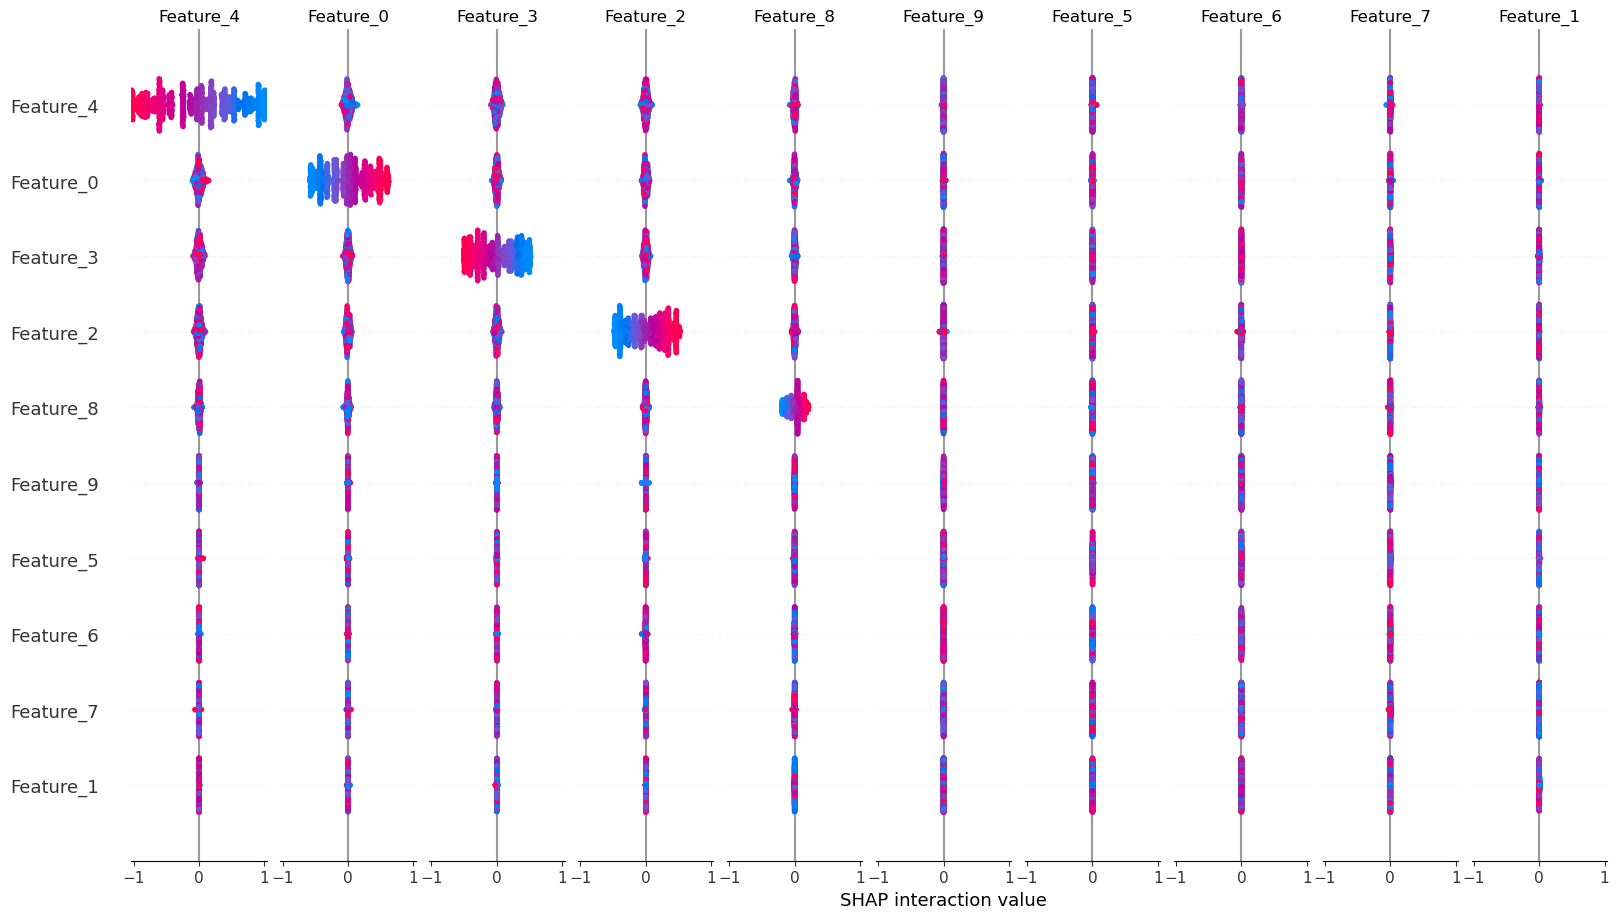


Strongest Interaction found by SHAP: Feature_4 & Feature_0
Plotting pure interaction effect for Feature_4 and Feature_0...


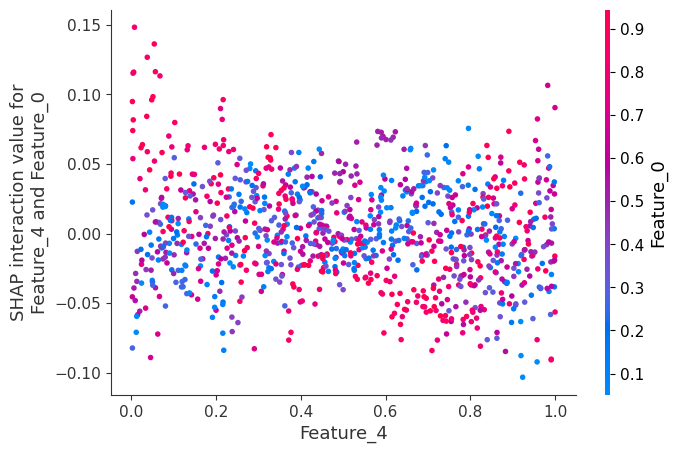

In [24]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [25]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_4: 0.5494
  Feature_0: 0.3211
  Feature_3: 0.2646
  Feature_2: 0.2571
  Feature_8: 0.1095
  Feature_9: 0.0036
  Feature_5: 0.0034
  Feature_6: 0.0030
  Feature_7: 0.0022
  Feature_1: 0.0020

Ranked Features (Most to Least Important):
['Feature_4', 'Feature_0', 'Feature_3', 'Feature_2', 'Feature_8', 'Feature_9', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_1']
